In [1]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
import flammkuchen as fl
from ipywidgets import interact, Dropdown, IntSlider

from nutil.plot import paperStyle

/data/du92wufe/.conda/envs/airway/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.1
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
# specify GA results folder here
ga_run = 'ga_20230202-082119_sc_2d_4classes_selection50_mutation20'

ga_path = Path('Results/' + ga_run)
with open(ga_path / 'params.json') as f:
    params = json.loads(f.read())

In [3]:
def get_boundaries(values):
    threshold = 3_850
    start = None
    end = None
    for val in values:
        if start is None and val > threshold:
            start = int(np.where(val == values)[0])
        elif start is not None and val < threshold:
            end = int(np.where(val == values)[0])
            break
    return start, end

def add_unit(objective):
    if objective == "memory_footprint_h5" or objective == "memory_footprint_tflite" or objective == "memory_footprint_c_array":
        return objective + " [B]"
    elif objective == "inference_time":
        return objective + " [ms]"
    elif objective == "energy_consumption":
        return objective + " [mJ]"
    elif objective == "mean_power_consumption":
        return objective + " [mA]"
    else:
        return objective

def plot_individual(gen, ind):
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(10, 5))
    ind_path = ga_path / gen / ind
    
    # plot overview table
    with open(ind_path / "results.json") as f:
        d = json.loads(f.read()) 
    
    try:
        d["mean_power_consumption"] = str(float(d["mean_power_consumption"])*1000)
    except:
        pass
        
    ax1.axis('off')
    ax1.axis('tight')
    table = ax1.table(cellText=[[str(d[key])[:7]] for key in d], rowLabels=[add_unit(str(key)) for key in d], loc='center') 
    table.scale(0.8, 1)  # may help
    
    # plot training/validation accuracy
    history = fl.load(ind_path / "history.fl")
    ax2.plot(history['loss'], marker="x")
    ax2.plot(history['val_loss'], marker="x")
    ax2.set_xlabel("Epochs")
    ax2.set_ylabel("Loss")
    
    # plot power consumption measurements
    try:
        data = pd.read_csv(ind_path / "power_measurements.csv")
        values = np.asarray(data["Power Consumption"])
        start, end = get_boundaries(values)
        if start is not None and end is not None:
            values = values[start-1000:end+1000]
            start, end = get_boundaries(values)
        x = np.arange(0, len(values), 1)
        ax3.plot(x, values, color='black', alpha=0.7)
        ax3.set_ylabel("Electric current [uA]")
        ax3.set_xlabel("Time [au]")
        
        
        ax3.vlines(start, 2000, 10_000, color='red')
        ax3.vlines(end, 2000, 10_000, color='red')
        ax3.set_ylim(min(values), max(values)+100)
        ax3.fill_between(x[start:end], values[start:end], color='orange', alpha=0.6)
    except Exception as e:
        print(str(e))
    
    # plot training/validation loss
    ax4.plot(history['accuracy'], label="train", marker="x")
    ax4.plot(history['val_accuracy'], label="val", marker="x")
    #ax4.set_ylim([0, 1])
    ax4.set_xlabel("Epochs")
    ax4.set_ylabel("Accuracy")
    ax4.legend()
    
    plt.tight_layout()

## Single individuals

In [4]:
# get generations and all individuals saved in a dictionary
d = {}
for i in range(1, params['generations'] + 1):
    gen = f"Generation_{i}"
    gen_path = ga_path / gen
    if not os.path.exists(gen_path):
        break
    d[gen] = os.listdir(gen_path)

# plot
generations = Dropdown(options = d.keys())
individuals = IntSlider(0, min=0, max=params['population_size']-1, step=1)

@interact(generation = generations, individual = individuals)
def plot_individual_interact(generation, individual):
    try:
        plot_individual(generation, d[generation][individual])
        plt.suptitle(d[generation][individual])
        plt.show()
    except:
        pass

interactive(children=(Dropdown(description='generation', options=('Generation_1', 'Generation_2', 'Generation_…

## Plot best individuals each generation

In [90]:
best_individuals = pd.read_csv(ga_path / "best_individual_each_generation.csv", names=["Generation", "Individual", "Fitness"], delimiter=",")
best_individuals["Generation"] = best_individuals["Generation"].apply(lambda x: x.replace(": ", "_"))
best_individuals['Fitness'] = pd.to_numeric(best_individuals['Fitness'])

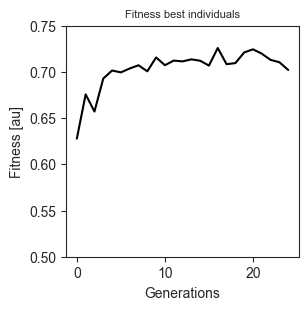

In [91]:
best_individuals.loc[(best_individuals['Fitness'] < -1000), 'Fitness'] = 0
best_individuals['Fitness'].plot(kind='line', color='black', figsize=(3, 3))

with paperStyle():
    plt.ylabel("Fitness [au]")
    plt.xlabel("Generations")
    plt.title("Fitness best individuals")
    plt.yticks([0.5, 0.55, 0.6, 0.65, 0.7, 0.75])

In [79]:
d = {}
for idx, row in best_individuals.iterrows():
    d[row['Generation']] = row['Individual']
    
# plot
generations = Dropdown(options = d.keys())

@interact(generation = generations)
def plot_individual_interact(generation):
    individual = d[generation]
    try:
        plot_individual(generation, individual)
        plt.suptitle(individual)
        plt.show()
    except:
        pass

interactive(children=(Dropdown(description='generation', options=('Generation_1', 'Generation_2', 'Generation_…

## Fitness over Generations

In [81]:
fitnesses_all = []
counters_all = []
counter_models_ok = np.zeros(2)

for i in range(1, params['generations'] + 1):
    fitnesses_generation = []
    counter_models_ok = np.zeros(2)
    
    if not os.path.exists(ga_path / f'Generation_{i}'):
        break
    
    for individual in os.listdir(ga_path / f'Generation_{i}'):
        with open(ga_path / f'Generation_{i}/{individual}/results.json') as f:
            results = json.loads(f.read())
            try:
                fitness = results['fitness']
                if fitness < -1000:
                    counter_models_ok[1] += 1
                else:
                    counter_models_ok[0] += 1
                    fitnesses_generation.append(fitness)
            except:
                # this means that there is no fitness in the file 
                # because the model was too big and so the fitness was not determined
                fitnesses_generation.append(0)
    fitnesses_all.append(fitnesses_generation)
    counters_all.append(counter_models_ok)
    
counters_all = np.asarray(counters_all)

In [82]:
fitnesses = []
fitnesses_std = []
for idx, f in enumerate(fitnesses_all):
    if idx == 28:
        continue
    fitnesses.append(np.mean(f))
    fitnesses_std.append(np.std(f)/2)
fitnesses_std = np.asarray(fitnesses_std)

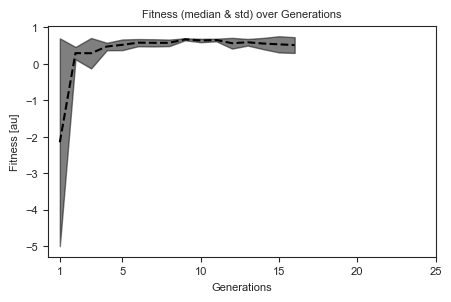

In [85]:
with paperStyle():
    plt.figure(figsize=(5,3))
    plt.plot(fitnesses, '--',color="black")
    plt.fill_between(np.arange(0, len(fitnesses_std)), fitnesses - fitnesses_std, fitnesses + fitnesses_std, color='black', alpha=0.5)
    plt.ylabel("Fitness [au]")
    plt.xlabel("Generations")
    plt.title("Fitness (median & std) over Generations")
    plt.xticks([0, 4, 9, 14, 19, 24], [1, 5, 10, 15, 20, 25])

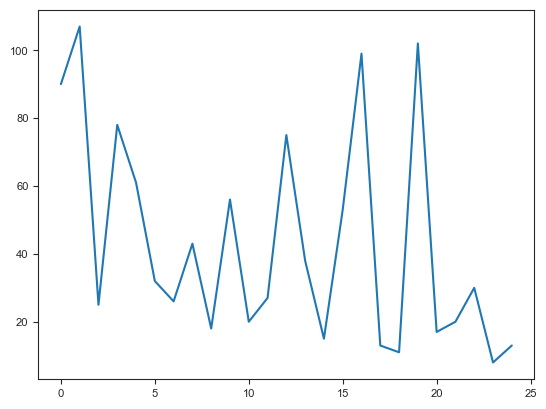

In [17]:
with paperStyle():
    plt.plot(counters_all[..., 0])

## Plot best individual of each generation

In [5]:
best_individuals = pd.read_csv(path / "best_individual_each_generation.csv", names=["Generation", "Individual", "Fitness"], delimiter=",")
best_individuals["Generation"] = best_individuals["Generation"].apply(lambda x: x.replace(": ", "_"))

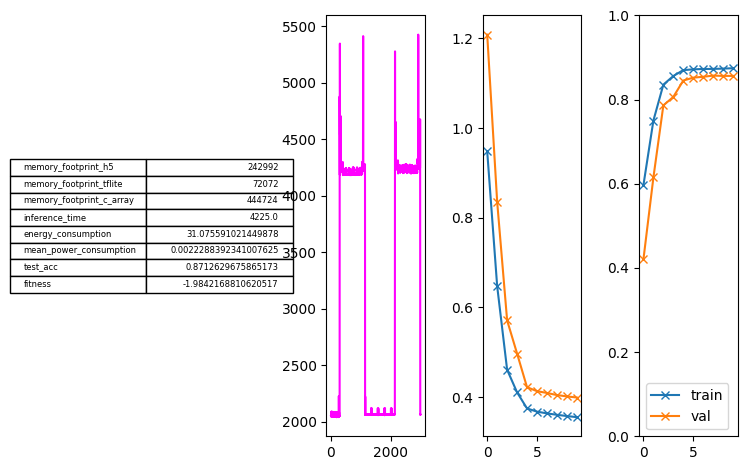

In [6]:
for idx, row in best_individuals.iterrows():
    path_individual = path / row["Generation"] / row["Individual"]
    plot_summary_individual(path_individual)
    if idx == 6:
        break


In [4]:
def get_objective_values(ga_path, objective):
    with open(ga_path / "params.json") as f:
        params = json.loads(f.read())
    
    return_list = []
    for i in range(1, params['generations']):
        gen_path = ga_path / f"Generation_{i}"
        if not os.path.exists(gen_path):
            break
        gen_results = []
        for ind in os.listdir(gen_path):
            ind_path = gen_path / ind
            with open(ind_path / "results.json") as f:
                results = json.loads(f.read())
            try:
                gen_results.append(results[objective])
            except:
                continue
        
        return_list.append(gen_results)
    
    return return_list

#### Test Accuracies

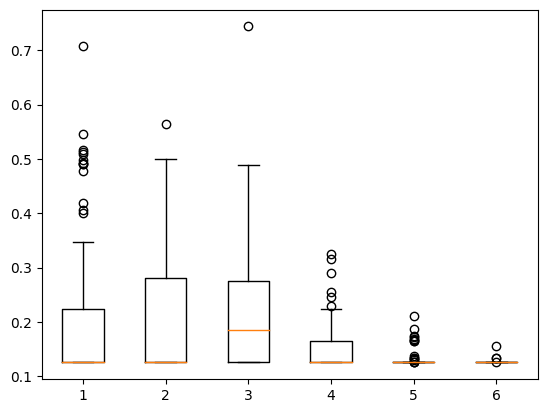

In [12]:
test_accs = get_objective_values(path, "test_acc")
plt.boxplot(test_accs)
plt.show()

#### Memory footprints

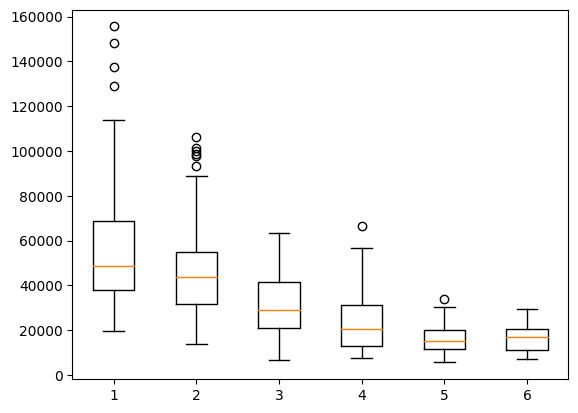

In [6]:
memory_footprint_tflite = get_objective_values(path, "memory_footprint_tflite")
plt.boxplot(memory_footprint_tflite)
plt.show()

#### Power consumption

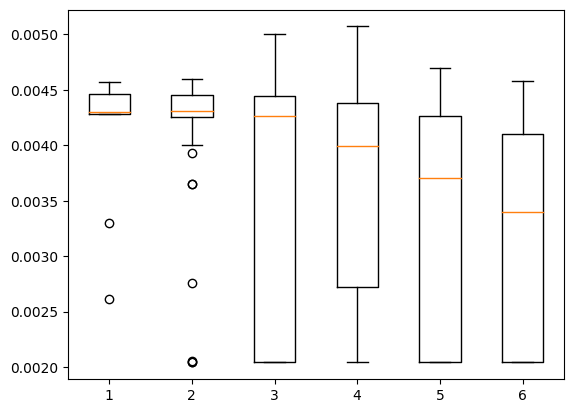

In [7]:
mean_power_consumption = get_objective_values(path, "mean_power_consumption")
plt.boxplot(mean_power_consumption)
plt.show()

#### Inference time

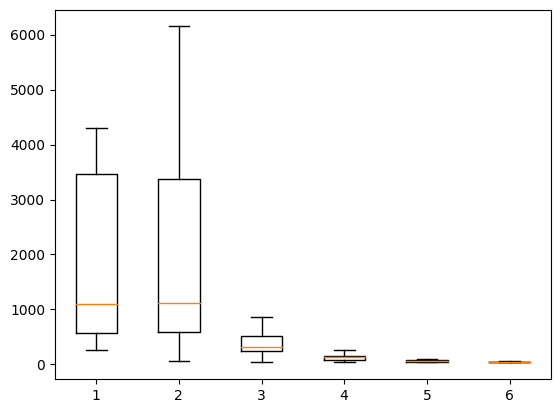

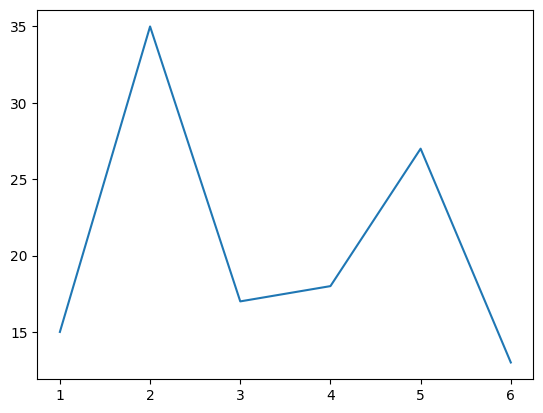

In [8]:
inference_time = get_objective_values(path, "inference_time")
inf_times, errors = [], []
for gen in inference_time:
    i_t, e = [], []
    for inf_time in gen:
        if type(inf_time) == float:
            i_t.append(inf_time)
        else:
            e.append(inf_time)
        
    inf_times.append(i_t)
    errors.append(len(e))
plt.boxplot(inf_times,showfliers=False)
plt.show()

plt.plot(np.arange(1, len(errors)+1), errors)
plt.show()

#### Fitness

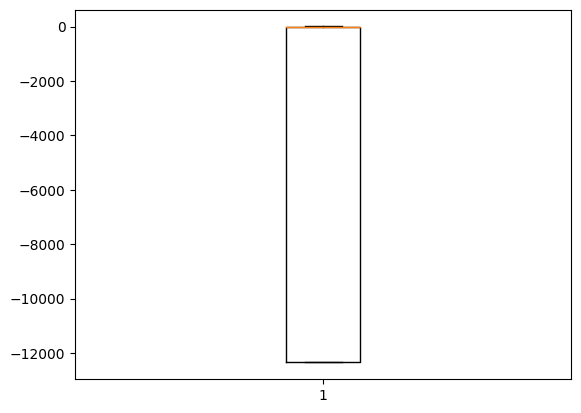

In [17]:
fitness = get_objective_values(path, "fitness")
plt.boxplot(fitness[fitness)
plt.show()

In [34]:
def plot_generation_summary(gen_path):
    individuals = os.listdir(gen_path)
    epochs_trained = []
    power_consumptions = []
    memory_footprints = []
    for ind in individuals:
        ind_path = gen_path / ind
        
        # nb epochs
        history = fl.load(ind_path / "history.fl")
        epochs_trained.append(len(history["val_loss"]))
        
        # power measurements and size of network
        with open(gen_path / ind / "results.json") as f:
            d = json.loads(f.read()) 
          
        try:
            power_consumption = d["mean_power_consumption"]
            power_consumption = float(power_consumption)        
            power_consumptions.append(power_consumption)
            memory_footprints.append(d["memory_footprint_tflite"])
        except:
            print(d["energy_consumption"])
            pass
        
        
    #plt.scatter(np.ones(len(epochs_trained))+np.random.uniform(-0.2, 0.2, len(epochs_trained)), epochs_trained)
    #plt.show()
    
    plt.scatter(power_consumptions, memory_footprints)
    #plt.xlim(0.0038, 0.0048)
    plt.ylabel("Memory footprint bytes")
    plt.xlabel("power cons A")
    

In [40]:
from ipywidgets import interact, IntSlider

In [42]:
@interact
def showGen(g=IntSlider(1,1,20)):
    gen = f"Generation_{g}"
    plot_generation_summary(path / gen)

interactive(children=(IntSlider(value=1, description='g', max=20, min=1), Output()), _dom_classes=('widget-int…

In [6]:
fitnesses_all = []
for i in range(1, params['generations'] + 1):
    fitnesses_generation = []
    try:
        for individual in os.listdir(path + f'/Generation_{i}'):
            with open(path + f'/Generation_{i}/{individual}/results.json') as f:
                results = json.loads(f.read())
                try:
                    fitnesses_generation.append(results['fitness'])
                except:
                    # this means that there is no fitness in the file 
                    # because the model was too big and so the fitness was not determined
                    fitnesses_generation.append(0)
        fitnesses_all.append(fitnesses_generation)
    except:
        pass

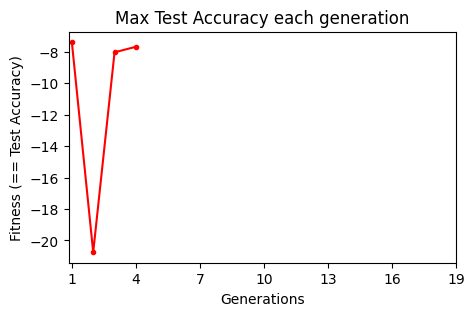

In [7]:
plt.figure(figsize=(5, 3))
plt.plot(np.arange(1, len(fitnesses_all) + 1), np.max(fitnesses_all, axis=1), 'r.-')
#plt.errorbar(np.arange(1, len(fitnesses_all) + 1), np.max(fitnesses_all, axis=1), np.std(fitnesses_all, axis=1))
plt.xticks(np.arange(1, 20, 3))
plt.xlabel('Generations')
plt.ylabel('Fitness')
plt.title("Max Test Accuracy each generation")
plt.show()

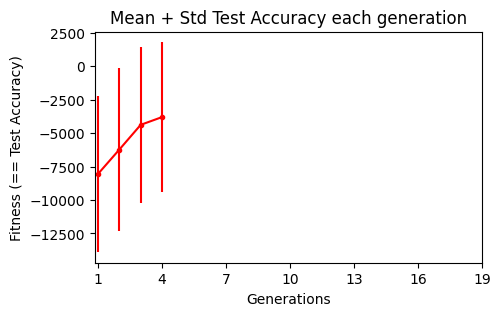

In [8]:
plt.figure(figsize=(5, 3))
plt.errorbar(np.arange(1, len(fitnesses_all) + 1), np.mean(fitnesses_all, axis=1), np.std(fitnesses_all, axis=1), fmt='r.-')
plt.xticks(np.arange(1, 20, 3))
plt.xlabel('Generations')
plt.ylabel('Fitness')
plt.title("Mean + Std Fitness each generation")
plt.show()

In [12]:
memory_footprints_all = []
for i in range(1, params['generations'] + 1):
    footprints_generation = []
    try:
        for individual in os.listdir(path + f'/Generation_{i}'):
            with open(path + f'/Generation_{i}/{individual}/results.json') as f:
                results = json.loads(f.read())         
                try:
                    footprints_generation.append(results['memory_footprint_tflite'])
                except:
                    # this means that there is no fitness in the file 
                    # because the model was too big and so the fitness was not determined
                    footprints_generation.append(0)
        memory_footprints_all.append(footprints_generation)
    except:
        pass

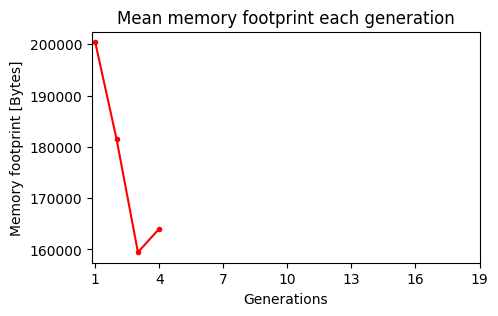

In [13]:
plt.figure(figsize=(5, 3))
plt.plot(np.arange(1, len(memory_footprints_all) + 1), np.mean(memory_footprints_all, axis=1), 'r.-')
#plt.errorbar(np.arange(1, len(memory_footprints_all) + 1), np.mean(memory_footprints_all, axis=1), np.std(memory_footprints_all, axis=1))
plt.xticks(np.arange(1, 20, 3))
plt.xlabel('Generations')
plt.ylabel('Memory footprint [Bytes]')
plt.title("Mean memory footprint each generation")
plt.show()

In [2]:
import nvidia_smi

In [3]:
nvidia_smi.nvmlInit()

handle = nvidia_smi.nvmlDeviceGetHandleByIndex(0)

In [4]:
info = nvidia_smi.nvmlDeviceGetMemoryInfo(handle)

print("Total memory:", info.total)
print("Free memory:", info.free)
print("Used memory:", info.used)

nvidia_smi.nvmlShutdown()

Total memory: 25434652672
Free memory: 12030509056
Used memory: 13404143616
